# 04. 문제 유형별 출력층 설계

딥러닝 모델의 마지막 층은 문제 유형에 따라 달라진다.
회귀는 연속값을 예측하므로 출력 뉴런 수가 예측할 숫자 개수와 같고, 보통 별도의 활성화 없이 값을 그대로 낸다.
이진 분류는 한 클래스에 속할 확률을 예측하므로 출력 뉴런 1개를 사용하고, 다중 분류는 클래스 수만큼 logits를 출력한다.

출력층 설계는 손실함수 선택과 항상 함께 봐야 한다.
- 회귀: `MSELoss`나 `L1Loss`
- 이진 분류: `BCELoss` 또는 `BCEWithLogitsLoss`
- 다중 분류: `CrossEntropyLoss`

특히 PyTorch의 `BCEWithLogitsLoss`는 sigmoid와 BCE를 안정적으로 결합하고,
`CrossEntropyLoss`는 softmax 전의 logits를 입력받는다.

학생들이 자주 헷갈리는 부분은 "모델 출력에 sigmoid/softmax를 먼저 적용해야 하는가"이다. PyTorch에서는 손실함수가 내부에서 처리하는 경우가 많으므로, 출력층과 손실함수의 짝을 정확히 맞추는 것이 중요하다.


# 출력층 설계 (Output layer)

**회귀 vs 분류 출력층 비교표**

| 항목           | **회귀 (Regression)**            | **이진 분류 (Binary Classification)**        | **다중 분류 (Multi-class Classification)** |
| ------------ | ------------------------------ | ---------------------------------------- | -------------------------------------- |
| **출력층 뉴런 수** | 1개                             | 1개                                       | 클래스 수만큼 (예: 3개 클래스 → 3개 뉴런)            |
| **활성화 함수**   | 없음 (`Identity` = 항등함수)         | `Sigmoid`                                | 없음 (출력은 로짓값, softmax는 loss 내부 처리)      |
| **손실 함수**    | `MSELoss`, `L1Loss` 등          | `BCELoss`, `BCEWithLogitsLoss`           | `CrossEntropyLoss` (Softmax 포함)        |
| **정답 레이블**   | 실수 (float32), shape = `(n, 1)` | 0 또는 1 (float or long), shape = `(n, 1)` | 정수 (long), shape = `(n,)`              |
| **예측 방식**    | 그대로 출력 사용 (`ŷ`)                | `ŷ >= 0.5` → 1, else 0                   | `argmax(output, dim=1)`                |

<br/>

> 회귀는 **출력값에 제한이 없으므로** 아무 활성화도 적용하지 않음
>
> 이진 분류는 **확률**을 출력해야 하므로 sigmoid를 씌움. `BCEWithLogitsLoss` 사용하는 경우에는 **출력층에서는 sigmoid를 쓰지 않음**
>
> 다중 분류는 `CrossEntropyLoss`가 내부적으로 `Softmax` + `Log`를 처리하므로 **출력층에서는 softmax를 쓰지 않음**


## 회귀 출력층
항등함수란? $f(x) = x$와 같이 입력이 곧 출력이 함수를 가리킨다.
torch모델에서는 출력층 다음에 아무 활성화 함수를 사용하지 않는다.

#### 출력층 실습 라이브러리 불러오기

회귀, 이진 분류, 다중 분류 실습에 필요한 PyTorch와 sklearn 도구를 준비한다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# F: 활성화 함수(sigmoid, ReLu, softmax)
import torch.nn.functional as F

# optim : Optimizer를 제공해 파라미터 최적화 업데이트 담당
import torch.optim as optim


#### 회귀용 합성 데이터 생성

회귀 문제는 출력층이 연속값 1개를 예측하도록 데이터를 구성한다.


In [2]:
# 가중치, 편향이 정해진 합성 회귀 데이터를 생성
X = torch.randn(100, 2)

W = torch.tensor([[3., 2.]])
b = torch.tensor([5.])

noise = torch.randn(100, 1) * 2

y = X @ W.T + b + noise


#### 회귀 모델 구조 정의

회귀 모델의 마지막 출력층은 활성화 함수 없이 실수값 1개를 반환한다.


In [3]:
class RegressionNet(nn.Module):

    # 출력층 출력 개수는 1개로 고정이라 별도로 전달받지 않음
    def __init__(self, input_dim):
        super().__init__()

        self.hidden = nn.Linear(input_dim, 10)
        self.relu = nn.ReLU() # hidden layer activation function

        # 출력층 (입력 10, 출력 1개)
        # 회귀모델은 활성화 함수 X -> 1개의 출력 값이 예측값 자체임
        self.output = nn.Linear(10, 1)

    # 순전파
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

# 딥러닝 모델 생성
model = RegressionNet(input_dim=X.size(1)) # X.size(1) == 2

# 생성된 모델의 예측 결과와 실제값의 오차 측정 == 손실함수
# MSELoss(Mean Squared Error): 예측값과 실제값의 평균 제곱오차
# - 예측값과 실제값을 비교해 loss 값을 만듦(최적화 시 사용됨)
criterion = nn.MSELoss()

# 오차를 줄이는 방향으로 W, b를 최적화함
# 이때 위의 loss 값을 이용함
optimizer = optim.Adam(model.parameters(), lr=0.01)

#### 회귀 모델 학습 루프

MSELoss와 optimizer.step 흐름으로 연속값 예측 오차를 줄인다.


In [4]:
# 회귀 모델의 학습 루프를 3천번 반복해 MSELoss 값을 줄이기
# == 예측 정확도 증가시키기

# epoch: 1회 전체 학습 단위
# - 전체 학습 데이터로 순전파 -> 손실함수 -> 최적화까지 진행한 횟수
for epoch in range(3000):

    # 모델을 학습 모드로 전환
    model.train()

    # 이전 학습 최적화 진행 시 계산한 기울기를 지우기
    # -> 이전 학습 기울기가 누적되지 않은 상태로 새로 학습
    optimizer.zero_grad()

    # 순전파(forward()): X에 대한 예측 결과 반환
    pred = model(X)

    # loss 계산(nn.MSELoss() 호출)
    loss = criterion(pred, y)

    # 오차 역전파(backward())
    # - loss를 줄이기 위해서는 각 뉴런의 W, b를 수정해야되기 때문에
    #   모델 학습 방향을 반대로 돌림
    # - W,b를 얼마나 바꿔야하는지 기울기 계산이 진행됨(자동 미분)
    # - 이 단계에서는 아직 W,b가 업데이트 되진 않음
    loss.backward()

    # loss에서 계산된 기울기와 lr(learning rate)에 맞춰
    # W, b를 수정
    optimizer.step()

    if(epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}: Loss {loss.item()}')

# loss가 학습을 반복하면서 줄어들고 있는 것을 확인
# == optimizer가 올바른 방향으로 수정하고 있다라는 뜻

# loss가 거의 줄지 않는 상태
# == learning rate, 모델 구조, 입력과 정답의 shape, dtype 확인 필요

# loss만 가지고는 모델의 성능을 일반화 시켜서 판단할 순 없음

Epoch 100: Loss 3.0741851329803467
Epoch 200: Loss 2.86021089553833
Epoch 300: Loss 2.8268637657165527
Epoch 400: Loss 2.8147382736206055
Epoch 500: Loss 2.808229446411133
Epoch 600: Loss 2.802839994430542
Epoch 700: Loss 2.791496992111206
Epoch 800: Loss 2.7667126655578613
Epoch 900: Loss 2.7655582427978516
Epoch 1000: Loss 2.7648651599884033
Epoch 1100: Loss 2.764540433883667
Epoch 1200: Loss 2.7641124725341797
Epoch 1300: Loss 2.7637722492218018
Epoch 1400: Loss 2.763427734375
Epoch 1500: Loss 2.7629950046539307
Epoch 1600: Loss 2.762645959854126
Epoch 1700: Loss 2.7622830867767334
Epoch 1800: Loss 2.761812686920166
Epoch 1900: Loss 2.7614974975585938
Epoch 2000: Loss 2.761112928390503
Epoch 2100: Loss 2.7606852054595947
Epoch 2200: Loss 2.760422706604004
Epoch 2300: Loss 2.759938955307007
Epoch 2400: Loss 2.7595083713531494
Epoch 2500: Loss 2.7590572834014893
Epoch 2600: Loss 2.7587485313415527
Epoch 2700: Loss 2.758357048034668
Epoch 2800: Loss 2.757974147796631
Epoch 2900: Loss 2

#### 회귀 예측 결과 시각화

실제값과 예측값이 기준선 가까이에 모일수록 회귀 모델이 잘 맞은 것이다.


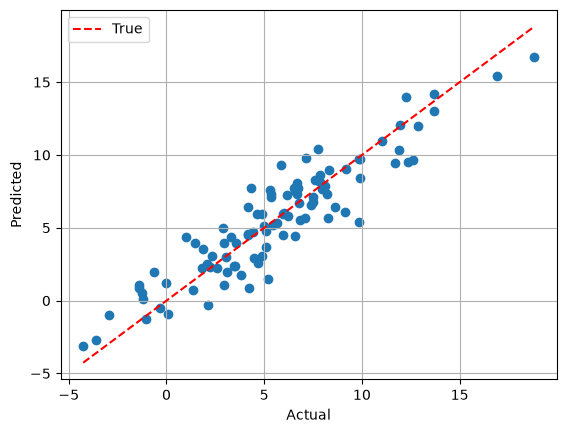

In [5]:
with torch.no_grad():

    model.eval()
    pred = model(X)

plt.scatter(y.numpy(), pred.numpy())

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='True')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid()
plt.show()


#### 모델 파라미터 shape 확인

named_parameters로 계층별 weight와 bias shape를 확인해 출력층 구조를 해석한다.


In [6]:
for name, param in model.named_parameters():

    print(f'{name}: {param.shape}')


hidden.weight: torch.Size([10, 2])
hidden.bias: torch.Size([10])
output.weight: torch.Size([1, 10])
output.bias: torch.Size([1])


### 캘리포니아 집값 예측

#### California Housing 데이터 전처리

딥러닝 회귀에서는 입력과 타깃 스케일링이 학습 안정성에 중요하다.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

X, y = fetch_california_housing(return_X_y=True, as_frame=True)
print(X.shape, y.shape)

X_scaler = StandardScaler()

# 회귀 target도 스케일링 진행
# 왜? 스케일링된 X에 비해 y값이 너무 크기 때문에 loss가 불안정해지기 때문에
# 이를 대비하기 위해 스케일링 진행
y_scaler = StandardScaler()

X = X_scaler.fit_transform(X)
y = y_scaler.fit_transform(y.values.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


(20640, 8) (20640,)


#### California 회귀 모델 직접 정의

여러 Linear와 ReLU 계층을 직접 선언해 회귀 네트워크를 구성한다.


In [8]:
class CaliforniaHousingNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.hidden1 = nn.Linear(input_dim, 32)
        self.relu1 = nn.ReLU()
        self.hidden2 = nn.Linear(32, 16)
        self.relu2 = nn.ReLU()

        self.output = nn.Linear(16, 1)

    def forward(self, x):
        x = self.hidden1(x)
        x = self.relu1(x)
        x = self.hidden2(x)
        x = self.relu2(x)
        x = self.output(x)
        return x


#### nn.Sequential 회귀 모델

- nn.Sequential 회귀 모델은 여러 신경망 계층을 실행할 순서대로 나열해서 만든 회귀 모델
- 단순히 앞에서 뒤로 흐르는 모델을 간결하게 작성할 때 사용한다.


In [9]:
class CaliforniaHousingNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        # 모듈 객체를 순서대로 묶고 실행(forward 구현체)
        # nn.Sequential(): 순서대로 이어지는 단순 신경망 구현시 사용
        self.net = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):

        return self.net(x)

model = CaliforniaHousingNet(input_dim=X.shape[1])

# "손실함수"를 이용한 오차 계산용 함수
criterion = nn.MSELoss()

# "최적화 알고리즘", 오차를 개선하는 방향으로 모델 파라미터(W,b)를 업데이트
optimizer = optim.Adam(model.parameters(), lr=0.01)


#### torchinfo로 모델 구조 확인

summary는 각 계층의 출력 shape와 파라미터 수를 확인하는 데 유용하다.


In [10]:
from torchinfo import summary

summary(model, input_data=X_train)


Layer (type:depth-idx)                   Output Shape              Param #
CaliforniaHousingNet                     [16512, 1]                --
├─Sequential: 1-1                        [16512, 1]                --
│    └─Linear: 2-1                       [16512, 64]               576
│    └─ReLU: 2-2                         [16512, 64]               --
│    └─Linear: 2-3                       [16512, 32]               2,080
│    └─ReLU: 2-4                         [16512, 32]               --
│    └─Linear: 2-5                       [16512, 1]                33
Total params: 2,689
Trainable params: 2,689
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 44.40
Input size (MB): 0.53
Forward/backward pass size (MB): 12.81
Params size (MB): 0.01
Estimated Total Size (MB): 13.35

#### California 회귀 모델 학습

train 모드에서 forward, loss, backward, step을 반복해 손실을 낮춘다.


In [11]:
model.train() # 모델을 학습 모드로 변경

for epoch in range(1000): # 모든 데이터의 학습 과정을 1000번 반복

    optimizer.zero_grad() # 이전 학습한 기울기 제거

    pred = model(X_train) # 예측

    loss = criterion(pred, y_train) # loss 계산

    loss.backward() # 오차 역전파 (+ 기울기 계산)

    optimizer.step() # 위에서 계산한 기울기 + lr을 이용해서 W,b를 업데이트(최적화)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}: Loss: {loss.item()}')


Epoch 100: Loss: 0.21830250322818756
Epoch 200: Loss: 0.20337362587451935
Epoch 300: Loss: 0.18485356867313385
Epoch 400: Loss: 0.17703478038311005
Epoch 500: Loss: 0.17079636454582214
Epoch 600: Loss: 0.1670083999633789
Epoch 700: Loss: 0.16791605949401855
Epoch 800: Loss: 0.16336603462696075
Epoch 900: Loss: 0.1582793891429901
Epoch 1000: Loss: 0.15605632960796356


#### 회귀 모델 평가 지표 계산

스케일링한 타깃을 원래 단위로 복원한 뒤 RMSE, MSE, MAE, R2를 계산한다.


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

model.eval()

with torch.no_grad():
    pred = model(X_test)

y_test_inv = y_scaler.inverse_transform(y_test)

pred_inv = y_scaler.inverse_transform(pred)

print(f'RMSE: {root_mean_squared_error(y_test_inv, pred_inv)}')
print(f'MSE: {mean_squared_error(y_test_inv, pred_inv)}')
print(f'MAE: {mean_absolute_error(y_test_inv, pred_inv)}')
print(f'R^2: {r2_score(y_test_inv, pred_inv)}')


RMSE: 0.5126790105609439
MSE: 0.2628397678697484
MAE: 0.34609134948790415
R^2: 0.7994215785786635


#### 회귀 예측 산점도

산점도와 기준선을 통해 실제값 대비 예측값의 분포를 시각적으로 확인한다.


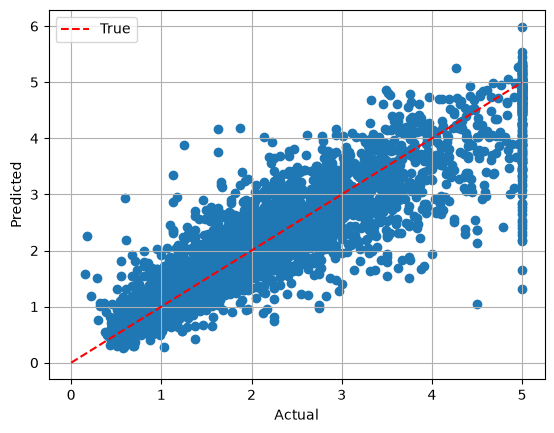

In [13]:
plt.scatter(y_test_inv, pred_inv)

plt.plot([0, y_test_inv.max()], [0, y_test_inv.max()], 'r--', label='True')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid()
plt.show()

# 기준선에 점이 가까움 == 오차가 적음 == 예측을 잘 함
# 특정 구간에서만 예측이 벌어짐 -> 해당 범위에 대한 예측이 평향됨을 의심

## 분류 출력층

### 이진분류
- Sigmoid 활성화 함수 사용
- 은닉층/출력층을 거쳐온 결과값(z)을 확률값(p)으로 변환
- 설정한 임계치 이상이면 양성으로 예측

#### 시그모이드와 임계값

이진 분류는 sigmoid 확률을 threshold 기준으로 0/1 클래스로 바꾼다.


In [14]:
torch.manual_seed(42)

# 생성된 난수 == 선형 방정식의 결과 취급 == z == logits (선형 방정식의 결과)
z = torch.randn(100) * 10

# sigmoid 활성화 함수를 이용해서 logits 값을 0~1사이 확률 값으로 변경
p = F.sigmoid(z)

threshold = 0.3 # 임계값

# 임계값 이상 == 1, 미만 0 으로 이진 분류
pred = (p >= threshold).int()

pd.DataFrame({
    'z': z.numpy(),
    'p': p.numpy(),
    'pred': pred.numpy(),
})


,z,p,pred
0,19.269154,1.000000e+00,1
1,14.872841,9.999996e-01,1
2,9.007172,9.998775e-01,1
3,-21.055210,7.175273e-10,0
4,6.784184,9.988697e-01,1
...,...,...,...
95,-3.036038,4.582411e-02,0
96,-9.864387,5.199107e-05,0
97,1.232991,7.743417e-01,1
98,3.498678,9.706501e-01,1


### 다중분류
- Softmax 활성화함수 사용
- 각 클래스별 계산값을 입력으로 받아, 각 클래스별 확률값으로 변환(모든 클래스의 확률값 합 1)
- 벡터를 입력받아 벡터로 반환

#### 단일 샘플 Softmax

Softmax는 한 샘플의 클래스 점수를 합이 1인 확률로 바꾼다.


In [15]:
z = torch.tensor([2., 1.5, 4, 0.7]) # 1행
print(z)

output = F.softmax(z, dim=0)
print(output) # 확률 합계가 1이 되는지 확인


tensor([2.0000, 1.5000, 4.0000, 0.7000])
tensor([0.1079, 0.0654, 0.7973, 0.0294])


#### 여러 샘플 Softmax

dim=1은 각 샘플 행 안에서 클래스 확률 합이 1이 되도록 계산한다.


In [16]:
z = torch.tensor([[2., 1.5, 4, 0.7],
                  [3., 1.1, 10.7, 1.9]])
print(z)

output = F.softmax(z, dim=1) # 각 행마다 확률 계산(행의 확률 합 1)
print(output)

pred = output.argmax(dim=1) # 각 행에서 최대값의 인덱스를 반환
print(pred)

print(output.sum(dim=1)) # 확률 합 1인지 확인


tensor([[ 2.0000,  1.5000,  4.0000,  0.7000],
        [ 3.0000,  1.1000, 10.7000,  1.9000]])
tensor([[1.0790e-01, 6.5443e-02, 7.9726e-01, 2.9405e-02],
        [4.5252e-04, 6.7683e-05, 9.9933e-01, 1.5063e-04]])
tensor([2, 2])
tensor([1.0000, 1.0000])


#### 다중 클래스에서 Sigmoid 사용 비교

Sigmoid는 클래스별 독립 확률이라 다중 클래스 단일 정답 문제에는 Softmax와 다르게 해석된다.


In [17]:
z = torch.tensor([[2., 1.5, 4, 0.7],
                  [3., 1.1, 10.7, 1.9]])
print(z)

p = F.sigmoid(z)
print(p)

pred = p.argmax(dim=1)
print(pred)

# softmax는 각 행을 하나의 단위로 묶어서 함수로 전달
# -> 예측 합계 합이 항상 1

# 각 logit을 독립적으로 sigmoid 함수에 전달하여 값을 변환
# -> 예측 합계가 1이 되지 않음
# -> 크기 순서로 sigmoid 결과값이 배정됨 -> 다중 분류에 적합하지 않음

tensor([[ 2.0000,  1.5000,  4.0000,  0.7000],
        [ 3.0000,  1.1000, 10.7000,  1.9000]])
tensor([[0.8808, 0.8176, 0.9820, 0.6682],
        [0.9526, 0.7503, 1.0000, 0.8699]])
tensor([2, 2])


### 출력층과 손실함수 연계

**이진분류**
- 출력층 sigmoid + 손실함수 BCELoss  <- 모델이 직접 sigmoid를 적용해 확률을 출력함
- 출력층 x + 손실함수 BCEWithLogitsLoss <- 모델은 sigmoid를 적용하지 않고 logit 원본을 출력하고, 손실 함수가 sigmoid를 적용한다.

**다중분류**
- 출력층 x + 손실함수 CrossEntropyLoss

#### 이진분류: 출력층 sigmoid + 손실함수 BCELoss

#### 이진 분류 데이터 생성

make_classification으로 이진 분류용 특성과 라벨을 만들고 Tensor로 변환한다.


In [18]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,
    n_features=10,
    n_informative=5,

    n_classes=2,
    random_state=42
)
print(X.shape, y.shape)

X = torch.tensor(X, dtype=torch.float32)

y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

print(X.shape, y.shape)


(100, 10) (100,)
torch.Size([100, 10]) torch.Size([100, 1])


#### Sigmoid 출력 이진 분류 모델

출력층에 Sigmoid를 붙이면 BCELoss에 넣을 확률값이 나온다.


In [2]:
class BinaryClassificationNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 64), # 은닉층
            nn.ReLU(),
            nn.Linear(64, 1), # 출력층(logits)
            nn.Sigmoid() # 0~1 사이 수로 변경
        )
    def forward(self, x):
        return self.net(x) # 0~1 사이 확률값이 반환

model = BinaryClassificationNet(input_dim=X.size(1))

# 손실함수
criterion = nn.BCELoss() # sigmoid 반환 값을 이용해서 loss 계산

# 최적화(W, b 업데이트)
optimizer = optim.Adam(model.parameters(), lr=0.01)


NameError: name 'nn' is not defined

#### BCELoss 기반 이진 분류 학습

확률값과 0/1 정답을 비교해 이진 분류 모델을 학습한다.


In [20]:
epochs = 100

model.train() # 학습 모드

for epoch in range(epochs):

    optimizer.zero_grad() # 이전 계산한 기울기 초기화

    pred = model(X) # 모델에 X 전달하여 결과 예측 (0.5 기준 0 또는 1 이진 분류)

    loss = criterion(pred, y) # 오차 측정(MSE, 100개 샘플의 오차 제곱의 평균값)

    loss.backward() # 오차역전파(오차를 줄이기 위한 각 파라미터의 기울기를 계산)
    optimizer.step() # 기울기 + lr를 이용하여 W, b 값을 수정

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Loss: {loss.item()}')


Epoch 10: Loss: 0.3445020914077759
Epoch 20: Loss: 0.1805356740951538
Epoch 30: Loss: 0.0992429330945015
Epoch 40: Loss: 0.0563899390399456
Epoch 50: Loss: 0.032550014555454254
Epoch 60: Loss: 0.020382830873131752
Epoch 70: Loss: 0.013685031794011593
Epoch 80: Loss: 0.009809279814362526
Epoch 90: Loss: 0.0074049485847353935
Epoch 100: Loss: 0.0058036441914737225


#### 출력층 x + 손실함수 BCEWithLogitsLoss

#### Logits 출력 이진 분류 모델

BCEWithLogitsLoss를 쓸 때는 출력층에 Sigmoid를 붙이지 않는다.


In [1]:
class BinaryClassificationNet2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 64), # 은닉층
            nn.ReLU(),
            nn.Linear(64, 1), # 출력층(logits)
        )
    def forward(self, x):
        return self.net(x) # logits(선형방정식 결과 z) 형태로 반환

model = BinaryClassificationNet2(input_dim=X.size(1))

# 손실함수 - BCEWithLogitsLoss
# - Logits를 이용해서 오차 계산하는 함수
# - 내부에 sigmoid와 BCE를 함께 처리해서 수치적으로 더 안정적인 결과를 반환
criterion = nn.BCEWithLogitsLoss()

# 최적화(W, b 업데이트)
optimizer = optim.Adam(model.parameters(), lr=0.01)


NameError: name 'nn' is not defined

#### BCEWithLogitsLoss 기반 학습

logits를 그대로 손실함수에 넣으면 내부에서 sigmoid와 BCE가 안정적으로 계산된다.


In [22]:
epochs = 100

model.train()

for epoch in range(epochs):

    optimizer.zero_grad()

    logits = model(X)

    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Loss: {loss.item()}')


Epoch 10: Loss: 0.37423980236053467
Epoch 20: Loss: 0.1877603530883789
Epoch 30: Loss: 0.10564418137073517
Epoch 40: Loss: 0.06148992478847504
Epoch 50: Loss: 0.03567531704902649
Epoch 60: Loss: 0.021716628223657608
Epoch 70: Loss: 0.014316266402602196
Epoch 80: Loss: 0.010105821304023266
Epoch 90: Loss: 0.0075778961181640625
Epoch 100: Loss: 0.005957684479653835


#### 유방암 예측

https://www.notion.so/shqkel/Datasets-1c39cb46e5e2818f8ae1c282ee5fadf8?p=1f39cb46e5e281c4876be717b656272b&pm=s

#### Breast Cancer 데이터 전처리

실제 이진 분류 데이터에서 스케일링, 분할, Tensor 변환을 수행한다.


In [31]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
print(X.shape, y.shape)

X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.dtype)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# unsqueeze(-1)의 목적
# - BCE 손실함수에 맞도록 y의 shape를 변경(N,1)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

print(X_train.dtype)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(569, 30) (569,)
float64
torch.float32
torch.Size([455, 30]) torch.Size([455, 1])
torch.Size([114, 30]) torch.Size([114, 1])


#### Breast Cancer 모델 정의

BCEWithLogitsLoss에 맞춰 마지막 계층은 logits 1개만 반환한다.


In [34]:
class BreastCancerNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__() # 부모 부분 생성 -> 파라미터 추적 ON

        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), # 은닉 1층
            nn.ReLU(), # 은닉 1층 결과의 활성화 함수
            nn.Linear(32, 16),  # 은닉 2층
            nn.ReLU(), # 은닉 2층 결과의 활성화 함수
            nn.Linear(16, 1) # 출력층
            # 활성화 함수 X -> logits 형태로 반환
        )

    def forward(self, x):
        return self.net(x)

# 모델 생성(입력값 X_train.size(1) == X_train 1행의 열의 수 == 30)
model = BreastCancerNet(input_dim = X_train.size(1))

# 손실함수(sigmoid + BCE 포함)
criterion = nn.BCEWithLogitsLoss()

# 파라미터 최적화
optimizer = optim.Adam(model.parameters(), lr=0.01)

#### Breast Cancer 모델 학습

이진 분류 학습 루프에서도 핵심 순서는 zero_grad, forward, loss, backward, step이다.


In [35]:
model.train()

for epoch in range(300):

    optimizer.zero_grad()

    pred = model(X_train)

    loss = criterion(pred, y_train)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Loss {loss.item()}')


Epoch 10: Loss 0.16548222303390503
Epoch 20: Loss 0.059130191802978516
Epoch 30: Loss 0.040447257459163666
Epoch 40: Loss 0.028412098065018654
Epoch 50: Loss 0.01994999498128891
Epoch 60: Loss 0.012150123715400696
Epoch 70: Loss 0.006872400175780058
Epoch 80: Loss 0.004036278463900089
Epoch 90: Loss 0.0025727504398673773
Epoch 100: Loss 0.0017569126794114709
Epoch 110: Loss 0.0012718342477455735
Epoch 120: Loss 0.0009666195837780833
Epoch 130: Loss 0.0007638856768608093
Epoch 140: Loss 0.0006219103815965354
Epoch 150: Loss 0.0005177333950996399
Epoch 160: Loss 0.0004394301795400679
Epoch 170: Loss 0.0003784933069255203
Epoch 180: Loss 0.00033029733458533883
Epoch 190: Loss 0.00029094828641973436
Epoch 200: Loss 0.00025877170264720917
Epoch 210: Loss 0.00023150786000769585
Epoch 220: Loss 0.0002087343018501997
Epoch 230: Loss 0.00018932073726318777
Epoch 240: Loss 0.0001723714522086084
Epoch 250: Loss 0.0001576939393999055
Epoch 260: Loss 0.00014493937487713993
Epoch 270: Loss 0.0001337

#### 이진 분류 모델 평가

logits를 sigmoid 확률로 바꾼 뒤 0.5 기준으로 클래스를 결정한다.


In [36]:
from sklearn.metrics import accuracy_score

model.eval() # 모델 평가 모드

with torch.no_grad():

    logits = model(X_test) # 학습 때 사용하지 않은 X_test 예측

    p = F.sigmoid(logits)

    pred = (p >= 0.5).int()

    print('정확도: ', accuracy_score(y_test, pred))


정확도:  0.956140350877193


#### 출력층 x + 손실함수 CrossEntropyLoss

#### 다중 분류 장난감 데이터와 모델

CrossEntropyLoss는 클래스별 logits와 정수 라벨을 입력으로 받는다.


In [48]:
torch.manual_seed(42) # 랜덤 시드 고정
X = torch.rand(4, 5) # 4행 5열 == 4개의 데이터, 특성 5개
print(X)

y = torch.tensor([0, 2, 1, 0]) # 정답

n_class = len(y.unique()) # 3 == 출력층 노드 수

# 모델 생성
class MultiClassificationNet(nn.Module):
    def __init__(self, input_dim, n_class):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), # 은닉층
            nn.ReLU(), # 은닉층 활성화 함수
            nn.Linear(32, n_class) # 출력층 (logits, 출력값 3개)
        )

    def forward(self, x):
        return self.net(x)

model = MultiClassificationNet(input_dim=X.size(1), n_class=n_class)

# 손실함수 -> 다중 분류용 손실함수인 CrossEntropyLoss 사용
# CrossEntropyLoss
# - 내부에 softmax와 NLLLoss를 내부에서 처리함
# - softmax에 전달할 데이터의 모습은 logit 형태
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)

tensor([[0.8823, 0.9150, 0.3829, 0.9593, 0.3904],
        [0.6009, 0.2566, 0.7936, 0.9408, 0.1332],
        [0.9346, 0.5936, 0.8694, 0.5677, 0.7411],
        [0.4294, 0.8854, 0.5739, 0.2666, 0.6274]])


#### 다중 분류 모델 학습

다중 분류에서는 softmax를 모델에 붙이지 않고 logits를 손실함수에 넣는다.


In [49]:
model.train()
for epoch in range(100):

    optimizer.zero_grad()

    logits = model(X)

    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Loss {loss.item()}')


Epoch 10: Loss 0.8434354066848755
Epoch 20: Loss 0.5997275710105896
Epoch 30: Loss 0.3533501625061035
Epoch 40: Loss 0.1756024956703186
Epoch 50: Loss 0.08264607191085815
Epoch 60: Loss 0.042740605771541595
Epoch 70: Loss 0.025621425360441208
Epoch 80: Loss 0.01753735914826393
Epoch 90: Loss 0.01314586866647005
Epoch 100: Loss 0.010451257228851318


#### 붓꽃데이터 예측

#### Iris 데이터 전처리

다중 분류 실습에서는 입력은 float Tensor, 정답은 long Tensor로 준비한다.


In [50]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
print(X.shape, y.shape)

X_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


(150, 4) (150,)


#### Iris 다중 분류 학습과 평가

logits를 softmax 확률로 바꾸고 argmax로 최종 클래스를 선택한다.


In [51]:
class IrisNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        return self.net(x)

model = IrisNet(input_dim=X_train.size(1), output_dim=3)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(100):
    optimizer.zero_grad()

    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Loss {loss.item()}')

model.eval()
with torch.no_grad():
    logits = model(X_test)
    print('logits:', logits[:2])

    p = F.softmax(logits, dim=1)
    print('p:', p[:2])

    pred = p.argmax(dim=1)
    print('pred:', pred[:2])
    print('y_true:', y_test[:2])
    print('정확도: ', accuracy_score(y_test, pred))


Epoch 10: Loss 0.40250492095947266
Epoch 20: Loss 0.22785227000713348
Epoch 30: Loss 0.1302189975976944
Epoch 40: Loss 0.08055683970451355
Epoch 50: Loss 0.05833476036787033
Epoch 60: Loss 0.04788466915488243
Epoch 70: Loss 0.04222144931554794
Epoch 80: Loss 0.03856981173157692
Epoch 90: Loss 0.035948995500802994
Epoch 100: Loss 0.033862244337797165
logits: tensor([[ 6.8814, -2.3631, -9.2703],
        [-4.9914,  1.5230,  2.8149]])
p: tensor([[9.9990e-01, 9.6633e-05, 9.6685e-08],
        [3.1930e-04, 2.1547e-01, 7.8422e-01]])
pred: tensor([0, 2])
y_true: tensor([0, 2])
정확도:  0.9666666666666667
